# Problem 1: Members of German Parliament

In [1]:
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
import seaborn as sns
from IPython.display import display

party_colours = {
    'PDS': "purple",
    'DIE LINKE': "#BE3075",
    'SPD': "#E3000F",
    'GRÜNE': "#1AA037",
    'FDP':"#FFEF00",
    'CDU': "#000000",
    'CSU': "#0570C9",
    'AfD': "#5B3626",
    'OTHER': "grey"
}

# Constants for data cleaning:
BASE = 'https://raw.githubusercontent.com/jolyphil/btmembers/main/csv/'
FACTION_MAP = {
    'Fraktion der SPD (Gast)': 'SPD',
    'Fraktion der Sozialdemokratischen Partei Deutschlands': 'SPD',
    'Fraktion der FDP (Gast)': 'FDP',
    'Fraktion der Freien Demokratischen Partei': 'FDP',
    'Fraktion Die Grünen': 'GRÜNE',
    'Fraktion Die Grünen/Bündnis 90': 'GRÜNE',
    'Fraktion BÜNDNIS 90/DIE GRÜNEN': 'GRÜNE',
    'Gruppe Bündnis 90/Die Grünen': 'GRÜNE',
    'Gruppe der Partei des Demokratischen Sozialismus/Linke Liste': 'PDS',
    'Gruppe der Partei des Demokratischen Sozialismus': 'PDS',
    'Fraktion der Partei des Demokratischen Sozialismus': 'PDS',
    'Fraktion Die Linke': 'DIE LINKE',
    'Fraktion DIE LINKE.': 'DIE LINKE',
    'Gruppe Die Linke': 'DIE LINKE',
    'Fraktion Alternative für Deutschland': 'AfD',
}

CDU_CSU_FACTIONS = {
    'Fraktion der CDU/CSU (Gast)',
    'Fraktion der Christlich Demokratischen Union/Christlich - Sozialen Union',
}

TODAY = pd.Timestamp('2026-07-25')

In [2]:
def safe_merge(df1, df2, key):
    for column in df2.columns:
        if column not in key and column in df1.columns:
            df1 = df1.drop(columns=column)
    return df1.merge(df2, on=key, how='left')

## 1.1 Storing the data

In [3]:
# Accessing the XML file:
xml_path = './data_bundestag/mdb-data.xml'
tree = ET.parse(xml_path)
root = tree.getroot()

# Storing mdb data:
mdbs_data = []
for mdb in root.findall('MDB'):
    info = mdb.find('INFO')
    mdb = {
        'ID': info.findtext('ID'),
        'First_name': info.findtext('First_name'),
        'Last_name': info.findtext('Last_name'),
        'Acad_Title': info.findtext('Acad_Title'),
        'Date_of_birth': info.findtext('Date_of_birth'),
        'Gender': info.findtext('Gender'),
        'Party': info.findtext('Party'),
        'Marital_status': info.findtext('Marital_status'),
        'Children': info.findtext('Children'),
    }
    mdbs_data.append(mdb)
mdb_df = pd.DataFrame(mdbs_data)

# Converting data types:
mdb_df['ID'] = mdb_df['ID'].astype(int)
mdb_df['Date_of_birth'] = pd.to_datetime(mdb_df['Date_of_birth'])
mdb_df['Children'] = mdb_df['Children'].astype(int)
mdb_df['Gender'] = mdb_df['Gender'].astype('category')
mdb_df['Party'] = mdb_df['Party'].astype('category')
mdb_df['Marital_status'] = mdb_df['Marital_status'].astype('category')
mdb_df['Acad_Title'] = mdb_df['Acad_Title']

# Storing wp data:
wp_data = []
for mdb in root.findall('MDB'):
    id = mdb.find('INFO').findtext('ID')
    wplist = mdb.find('WPLIST')
    for wp in wplist.findall('WP'):
        wp_entry = {
            'ID': int(id),
            'WP': int(wp.findtext('WP')),
            'MDBWP_FROM': wp.findtext('MDBWP_FROM'),
            'MDBWP_UNTIL': wp.findtext('MDBWP_UNTIL'),
            'WP_BEGIN': wp.findtext('WP_BEGIN'),
        }
        wp_data.append(wp_entry)
wp_df = pd.DataFrame(wp_data)

# Converting data types:
wp_df['MDBWP_FROM'] = pd.to_datetime(wp_df['MDBWP_FROM'])
wp_df['MDBWP_UNTIL'] = wp_df['MDBWP_UNTIL'].apply(
    lambda x: pd.to_datetime(x) if x != '/' else pd.NaT
)   # Handling open-ended dates (marked with "/").
wp_df['WP_BEGIN'] = pd.to_datetime(wp_df['WP_BEGIN'])

mdb_df

,ID,First_name,Last_name,Acad_Title,Date_of_birth,Gender,Party,Marital_status,Children
0,11000001,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
1,11000002,Ernst,Achenbach,Dr.,1909-04-09,male,FDP,married,3
2,11000003,Annemarie,Ackermann,None,1913-05-26,female,CDU,married,5
3,11000004,Else,Ackermann,Dr.,1933-11-06,female,CDU,no information / other,0
4,11000005,Ulrich,Adam,None,1950-06-09,male,CDU,married,2
...,...,...,...,...,...,...,...,...,...
4609,11005623,Reza,Asghari,Prof. Dr.,1961-04-01,male,CDU,married,2
4610,11005624,Andrea,Lübcke,Dr.,1978-12-09,female,GRÜNE,no information / other,2
4611,11005625,Lisa,Schubert,None,2002-09-06,diverse,DIE LINKE,no information / other,0
4612,11005626,Mayra,Vriesema,None,1999-12-25,female,GRÜNE,no information / other,0


## 1.2 Extracting terms

In [4]:
# Creating a terms data frame:
terms_df = (
    wp_df[['WP', 'WP_BEGIN']]
    .drop_duplicates(subset='WP')
    .sort_values('WP_BEGIN')
    .reset_index(drop=True)
)
terms_df['election_y_str'] = terms_df['WP_BEGIN'].dt.year.astype(str)
terms_df['election_y_int'] = terms_df['election_y_str'].astype(int)
    # Name election periods after the year they have begun.
terms_df

,WP,WP_BEGIN,election_y_str,election_y_int
0,1,1949-09-07,1949,1949
1,2,1953-10-06,1953,1953
2,3,1957-10-15,1957,1957
3,4,1961-10-17,1961,1961
4,5,1965-10-19,1965,1965
5,6,1969-10-20,1969,1969
6,7,1972-12-13,1972,1972
7,8,1976-12-14,1976,1976
8,9,1980-11-04,1980,1980
9,10,1983-03-29,1983,1983


## 1.3 Merging MDBs and WPs

To answer the questions, we need to merge MDB data like party membership and gender with WP information. For example, to find out which party was present in parliament at which time.

This merge is producing inconsistencies in the data, as mdb_df only shows the current party membership of the MDB. If an MDB sat the parliament for different parties at different times, this inconsistency causes retrospective party changes that disrespect the linearity of time. One example of an MDB whose entries are affected in such a way is Martin Hohmann, who got excluded from the CDU for his antisemetic speech in 2003. This made him an independent member of parliament, which is handled in our data as OTHER. Martin Hohmann later was reelected in 2017 as a member of the AfD. The merge would therefore show the presence of the AfD in parliament for the early 2000s in which the party did not even exist.

To solve this problem, we need to use external data. Our analysis of the Martin-Hohmann-Inconsistency is therefore based on the preprocessd data from 'https://raw.githubusercontent.com/jolyphil/btmembers/main/csv/' which is based on the official data from the German Bundestag. From this data we extract data of MDBs who are affected and create new rows for wp_df with the corrected entries. Afterwards, we replace the affected rows in wp_df by using name and date of birth as keys. The total number of new rows is 251.

In [5]:
# Merging wp_df and mdb_df:
wp_df = safe_merge(wp_df, mdb_df, ['ID'])

# Scraping more data about MDBs that switched parties over time to remove inconsistencies.
# See MD cell below for further explanation on why this is necessary.

# Loading data:
factions_df = pd.read_csv(BASE + 'inst.csv', dtype=str)
bio_df = pd.read_csv(BASE + 'bio.csv', dtype=str).set_index('id')
mdb_names_df = pd.read_csv(BASE + 'namen.csv', dtype=str)

# Reducing parliamentary groups to factions only:
factions_df = factions_df[factions_df['insart_lang'] == 'Fraktion/Gruppe'].copy()
factions_df['mdbins_von'] = pd.to_datetime(factions_df['mdbins_von'], errors='coerce')
factions_df['mdbins_bis'] = pd.to_datetime(factions_df['mdbins_bis'], errors='coerce')

# Use full names of the mdbs as primary keys:
mdb_names_df = mdb_names_df.sort_values('historie_von').groupby('id').last()[['nachname', 'vorname']]

def get_dob(mdb_id):
    return pd.to_datetime(bio_df.loc[mdb_id, 'geburtsdatum'])

def get_party(mdb_id, ins_long):
    """
    Categorizes the party affiliation of a member of the German Parliament
    based on their ID and the long name of their faction.
    :param mdb_id: int
    :param ins_long: str: long name of the faction
    :return: str: party
    """
    if ins_long in CDU_CSU_FACTIONS:
        party = bio_df.loc[mdb_id, 'partei_kurz'] if mdb_id in bio_df.index else None
        return 'CDU' if party == 'CDU' else 'CSU'
    return FACTION_MAP.get(ins_long, 'OTHER')

def format_date(datum):
    """
    Transforms dates into the format used in the rest of the analysis.
    """
    return pd.to_datetime(datum.date().isoformat()) if pd.notna(datum) else '/'

# Adding party memberships:
factions_df['party'] = \
    [get_party(id, faction) for id, faction in zip(factions_df['id'], factions_df['ins_lang'])]
factions_df = factions_df.sort_values(['id', 'mdbins_von'])

# Looking for MDBs who sat in the parliament for different parties at different times
# and building personal timelines:
defectors = []
for mdb_id, group in factions_df.groupby('id'):
    group = group.sort_values('mdbins_von')

    # Merging succeeding wps with the same party:
    timeline = []
    for party, start, end in zip(group['party'], group['mdbins_von'], group['mdbins_bis']):
        if timeline and timeline[-1][0] == party:
            timeline[-1] = (party, timeline[-1][1], end)
        else:
            timeline.append((party, start, end))

    switches = len(timeline) - 1
    if switches == 0:
        continue  # Switching in and out of the same party does not count as a party switch.

    lastn, firstn = mdb_names_df.loc[mdb_id, ['nachname', 'vorname']] #if mdb_id in mdb_names_df.index else ("?", "?")
    for i in range(switches):
        defectors.append({
            'First_name': firstn,
            'Last_name': lastn,
            'Date_of_birth': get_dob(mdb_id),
            'Party': timeline[i][0],
            'MDBWP_FROM': format_date(timeline[i][1]),
            'MDBWP_UNTIL': format_date(timeline[i][2])
        })

# Storing results:
defectors_df = pd.DataFrame(defectors)

# Adding WP info:
sorted_defectors_df = defectors_df.sort_values('MDBWP_FROM')
sorted_wp_df = wp_df.sort_values('WP_BEGIN')
wp_defectors_df = pd.merge_asof(
    sorted_defectors_df,
    sorted_wp_df[['WP', 'WP_BEGIN']],
    left_on='MDBWP_FROM',
    right_on='WP_BEGIN',
    direction='backward'
)

# Adding MDB info:
id_lookup = wp_df[['ID', 'First_name', 'Last_name', 'Acad_Title', 'Date_of_birth', 'Gender', 'Marital_status', 'Children']].drop_duplicates(
    subset=['First_name', 'Last_name', 'Date_of_birth'],
)
wp_defectors_df = safe_merge(wp_defectors_df, id_lookup, ['First_name', 'Last_name', 'Date_of_birth'])

# Replace inconsistent entries:
key_cols = ['First_name', 'Last_name','Date_of_birth', 'WP']
mask_to_remove = wp_df.set_index(key_cols).index.isin(
    wp_defectors_df.set_index(key_cols).index
)
wp_df_cleaned = wp_df[~mask_to_remove]
wp_df = pd.concat(
    [wp_df_cleaned, wp_defectors_df],
    ignore_index=True
).sort_values(['ID', 'WP']).reset_index(drop=True)

wp_df

,ID,WP,MDBWP_FROM,MDBWP_UNTIL,WP_BEGIN,First_name,Last_name,Acad_Title,Date_of_birth,Gender,Party,Marital_status,Children
0,11000001,5,1965-10-19,1969-10-19,1965-10-19,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
1,11000001,6,1969-10-20,1972-09-22,1969-10-20,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
2,11000001,7,1972-12-13,1976-12-13,1972-12-13,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
3,11000001,8,1976-12-14,1980-11-04,1976-12-14,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
4,11000001,9,1980-11-04,1983-03-29,1980-11-04,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13062,11005623,21,2025-06-10,NaT,2025-03-25,Reza,Asghari,Prof. Dr.,1961-04-01,male,CDU,married,2
13063,11005624,21,2025-07-01,NaT,2025-03-25,Andrea,Lübcke,Dr.,1978-12-09,female,GRÜNE,no information / other,2
13064,11005625,21,2025-08-01,NaT,2025-03-25,Lisa,Schubert,None,2002-09-06,diverse,DIE LINKE,no information / other,0
13065,11005626,21,2025-09-01,NaT,2025-03-25,Mayra,Vriesema,None,1999-12-25,female,GRÜNE,no information / other,0


## 2. Party composition per election period

To handle replacement MDBs and those who changed parties while in office, we choose to divide each MDB's time in office per election period by the total duration of that election period. The results are stored in a new column of wp_df and used to calculate the exact party compositions for each election period.

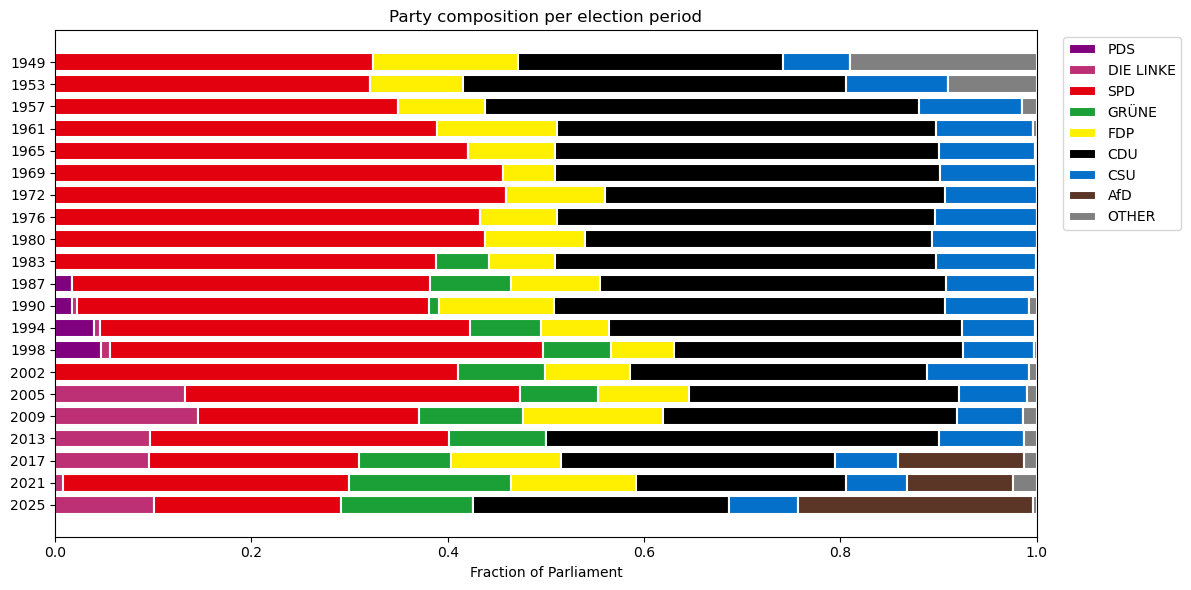

In [6]:
# Using the latest observed `MDBWP_UNTIL` per WP as the period end, assuming that at least one MDB per WP finishes his term:
terms_end_map = wp_df.dropna(subset=['MDBWP_UNTIL']).groupby('WP')['MDBWP_UNTIL'].max()

# WP 21 uses 2026-07-17 (today) as the end date for fraction calculation:
terms_end_map.loc[terms_df.loc[terms_df['WP_BEGIN'] == pd.Timestamp('2025-03-25'), 'WP'].iloc[0]] = TODAY

# Calculating the duration of each term:
terms_duration_map = (terms_end_map - terms_df.set_index('WP')['WP_BEGIN']).dt.days
terms_end_dates = wp_df['WP'].map(terms_end_map)
wp_end_dates = wp_df['MDBWP_UNTIL'].fillna(terms_end_dates)

# Calculating the duration of each wp_df entry:
wp_duration = (wp_end_dates - wp_df['MDBWP_FROM']).dt.days

# Calculating fractions:
wp_df['Frac_of_WP'] = (wp_duration / wp_df['WP'].map(terms_duration_map)).astype(float)

# Aggregating fractions per WP and party:
fractions = wp_df.groupby(['WP','Party'])['Frac_of_WP'].sum().unstack(fill_value=0)
    # Replace NaNs with 0.

# Normalizing rows to 1:
fractions_norm = fractions.div(fractions.sum(axis=1).replace({0:1}), axis=0)
wps = fractions_norm.index.tolist()
y_pos = np.arange(len(wps))

# Plot as 100% stacked bar chart:
fig, ax = plt.subplots(figsize=(12, max(6, int(len(wps)*0.25))))
left = np.zeros(len(wps))
for party in party_colours.keys():
    vals = fractions_norm[party].values
    ax.barh(terms_df['election_y_str'], vals, left=left, color=party_colours.get(party), edgecolor='white', linewidth=1.5)
    left = left + vals
ax.set_xlabel('Fraction of Parliament')
ax.set_title('Party composition per election period')
ax.set_xlim(0,1)
ax.invert_yaxis()
ax.legend(party_colours.keys(), bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. Gender compositions

In [7]:
def get_gender_ratio(group):
    gender_weight = (
    wp_df
    .groupby(group)['Frac_of_WP']
    .sum()
    .unstack(fill_value=0)
    )

    male_share = gender_weight['male'] / gender_weight.sum(axis=1)
    gender_ratio = (-2 * (male_share - 0.5)).rename('gender_ratio').reset_index()
    return safe_merge(terms_df[['WP', 'election_y_int']], gender_ratio, ['WP'])

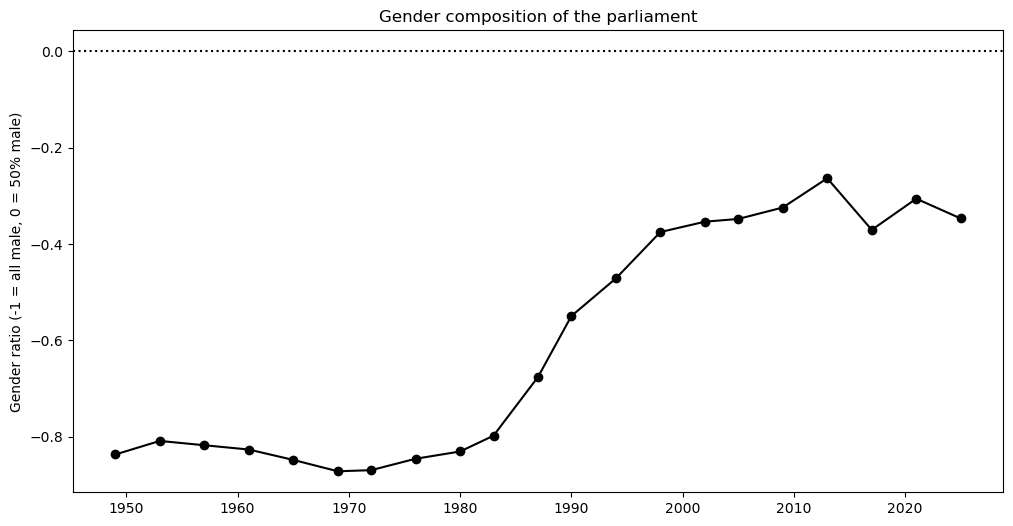

In [8]:
wp_gender_df = get_gender_ratio(['WP', 'Gender'])

fig, ax = plt.subplots(figsize=(12, max(6, int(len(wp_gender_df)*0.25))))
ax.axhline(0, color="black", linestyle=':')
ax.plot(wp_gender_df['election_y_int'], wp_gender_df['gender_ratio'], marker='o', color='black')
ax.set_ylabel('Gender ratio (-1 = all male, 0 = 50% male)')
ax.set_title('Gender composition of the parliament')
plt.show()

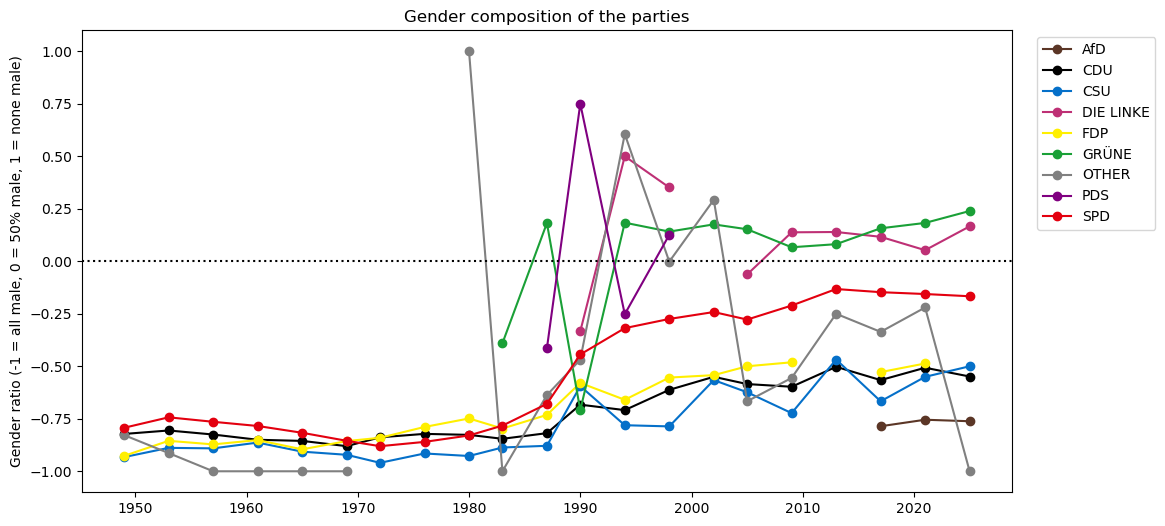

In [9]:
wp_parties_df = get_gender_ratio(['WP', 'Party', 'Gender'])

#wp_df = wp_df.merge(mdb_df, on='ID', how='left')


#full_terms_order = terms_df[['WP', 'election_y_int']].sort_values('WP').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12, max(6, int(terms_df.shape[0] * 0.25))))

for party, group in wp_parties_df.groupby('Party'):
    # Reindex to the full terms range; missing terms become NaN and break the line
    group_full = (
        terms_df
        .merge(group[['WP', 'gender_ratio']], on='WP', how='left')
    )
    ax.plot(
        group_full['election_y_int'],
        group_full['gender_ratio'],
        marker='o',
        label=party,
        color=party_colours.get(party, 'grey')
    )

ax.set_ylabel('Gender ratio (-1 = all male, 0 = 50% male, 1 = none male)')
ax.set_xlabel('')
ax.set_title('Gender composition of the parties')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.axhline(0, color='black', linestyle=':')
plt.show()

## 4.1 Age of the parliament

Age is the MDB's age when entering parliament.

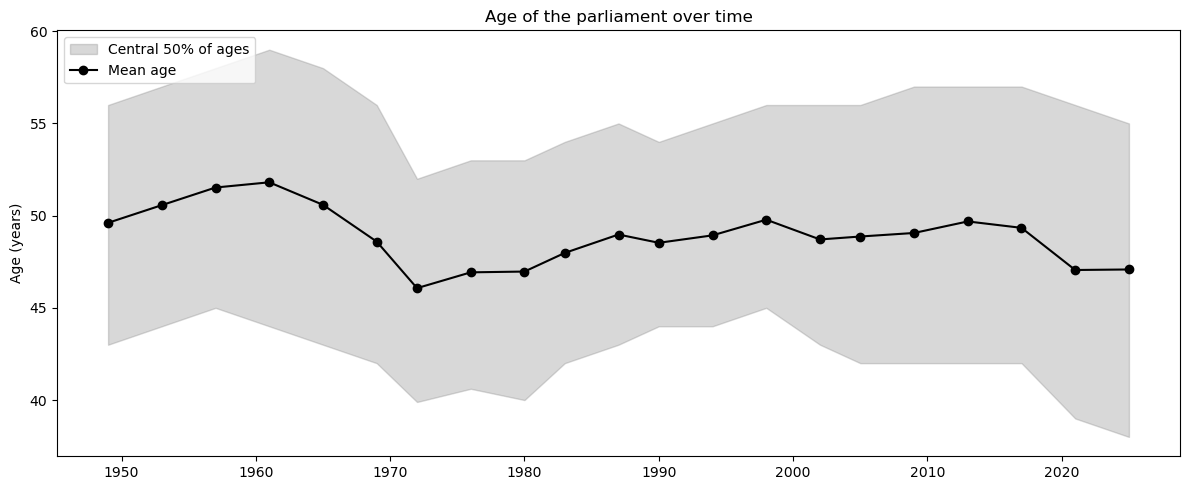

In [10]:
# Adding age column:
wp_df['Age'] = (
    (wp_df['MDBWP_FROM'] - wp_df['Date_of_birth']).dt.days // 365.25
).astype(int)

# Calculating age stats per party:
age_stats_df = (
    wp_df
    .groupby(['WP', 'Party'])['Age']
    .agg(
        age_min='min',
        age_q1=lambda x: x.quantile(0.25),
        age_median='median',
        age_q3=lambda x: x.quantile(0.75),
        age_max='max'
    )
    .reset_index()
)
wp_parties_df = safe_merge(wp_parties_df, age_stats_df, ['WP', 'Party'])
# Overall (whole-parliament) weighted mean age per WP
overall_age = (
    wp_df
    .groupby('WP')
    .apply(lambda g: (g['Age'] * g['Frac_of_WP']).sum() / g['Frac_of_WP'].sum(), include_groups=False)
    .rename('mean_age')
    .reset_index()
)

# Weighted 12.5th/87.5th percentile per WP -> covers the central 75% of ages,
# weighted by Frac_of_WP to properly account for partial-term members
def weighted_quantile(values, weights, q):
    sorter = np.argsort(values)
    values = np.array(values)[sorter]
    weights = np.array(weights)[sorter]
    cum_weights = np.cumsum(weights) - 0.5 * weights
    cum_weights /= np.sum(weights)
    return np.interp(q, cum_weights, values)

def age_envelope(g):
    lo = weighted_quantile(g['Age'], g['Frac_of_WP'], 0.25)
    hi = weighted_quantile(g['Age'], g['Frac_of_WP'], 0.75)
    return pd.Series({'age_lo': lo, 'age_hi': hi})

overall_range = (
    wp_df
    .groupby('WP')
    .apply(age_envelope, include_groups=False)
    .reset_index()
)

overall_age = (
    overall_age
    .merge(overall_range, on='WP')
    .merge(terms_df[['WP', 'election_y_int']], on='WP')
    .sort_values('WP')
)

fig, ax = plt.subplots(figsize=(12, 5))

# Grey envelope (central 75% of ages, weighted)
ax.fill_between(
    overall_age['election_y_int'],
    overall_age['age_lo'],
    overall_age['age_hi'],
    color='grey',
    alpha=0.3,
    label='Central 50% of ages'
)

# Mean age line
ax.plot(
    overall_age['election_y_int'],
    overall_age['mean_age'],
    marker='o',
    color='black',
    label='Mean age'
)

ax.set_xlabel('')
ax.set_ylabel('Age (years)')
ax.set_title('Age of the parliament over time')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 4.2 Age and gender compositions of the parties:

In [11]:
def compute_box_stats(values, whisker_factor=3/2):
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    median = values.median()
    iqr = q3 - q1

    lower_fence = q1 - whisker_factor * iqr
    upper_fence = q3 + whisker_factor * iqr

    whislo = values[values >= lower_fence].min()
    whishi = values[values <= upper_fence].max()

    fliers = values[(values < lower_fence) | (values > upper_fence)].tolist()

    return {
        'med': median,
        'q1': q1,
        'q3': q3,
        'whislo': whislo,
        'whishi': whishi,
        'fliers': fliers
    }

wp_to_year = terms_df.set_index('WP')['election_y_str'].to_dict()
wp_options = sorted(wp_df['WP'].unique())
default_wp = max(wp_options)

party_order = list(party_colours.keys())

# Fixed y-axis ranges across all WPs, so they don't rescale when switching elections
age_min_all = wp_df['Age'].min()
age_max_all = wp_df['Age'].max()
age_pad = (age_max_all - age_min_all) * 0.05
age_ylim = (age_min_all - age_pad, age_max_all + age_pad)

gender_axis_min = wp_parties_df['gender_ratio'].min()
gender_axis_max = wp_parties_df['gender_ratio'].max()
gender_pad = (gender_axis_max - gender_axis_min) * 0.05
gender_ylim = (min(gender_axis_min - gender_pad, -1.05), max(gender_axis_max + gender_pad, 1.05))

def overall_gender_ratio(df):
    weights = df.groupby('Gender')['Frac_of_WP'].sum()
    return 2 * (weights.get('female', 0) / weights.sum() - 0.5)

def plot_age_wp(wp):
    df_wp = wp_df[wp_df['WP'] == wp]

    present_parties = [p for p in party_order if p in df_wp['Party'].unique()]
    labels = present_parties + ['Overall']

    stats = []
    for party in present_parties:
        vals = df_wp.loc[df_wp['Party'] == party, 'Age']
        s = compute_box_stats(vals)
        s['label'] = party
        stats.append(s)

    overall_stats = compute_box_stats(df_wp['Age'])
    overall_stats['label'] = 'Overall'
    stats.append(overall_stats)

    # Gender ratios per party (from wp_parties_df), plus overall gender ratio
    gender_map = (
        wp_parties_df[wp_parties_df['WP'] == wp]
        .set_index('Party')['gender_ratio']
        .to_dict()
    )
    gender_values = [gender_map.get(p, np.nan) for p in present_parties]
    gender_values.append(overall_gender_ratio(df_wp))

    fig, ax_age = plt.subplots(figsize=(13, 6))
    ax_gender = ax_age.twinx()

    positions = range(1, len(stats) + 1)

    bxp_dict = ax_age.bxp(
        stats,
        positions=positions,
        patch_artist=True,
        widths=0.5,
        showfliers=True,
        medianprops={'color': 'black'},
        flierprops={'marker': 'x', 'markersize': 3}
    )

    for patch, label in zip(bxp_dict['boxes'], labels):
        color = party_colours.get(label, 'lightgrey') if label != 'Overall' else 'lightgrey'
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax_gender.scatter(
        positions,
        gender_values,
        color='white',
        edgecolor='black',
        s=80,
        zorder=5
    )

    ax_age.set_xticks(positions)
    ax_age.set_xticklabels(labels)
    ax_age.set_ylabel('Age (years)')
    ax_gender.set_ylabel(
        'Gender ratio (-1 = all male, 0 = 50%, 1 = none male)',
        rotation=270,
        labelpad=15
    )

    ax_age.set_ylim(age_ylim)
    ax_gender.set_ylim(gender_ylim)

    ax_age.set_title(f'Age and Gender Composition by Party — Election {wp_to_year[wp]}')

    plt.tight_layout()
    plt.show()

widgets.interact(
    plot_age_wp,
    wp=widgets.Dropdown(
        options=[(wp_to_year[wp], wp) for wp in wp_options],
        value=default_wp,
        description='Election:'
    )
)

interactive(children=(Dropdown(description='Election:', index=20, options=(('1949', np.int64(1)), ('1953', np.…

<function __main__.plot_age_wp(wp)>

## 4.3 Party and gender compositions of the age groups:

In [12]:
# Fixed 10-year age bins starting at 15 (so x-axis stays consistent across WPs):
age_max_global = int(wp_df['Age'].max() // 10 * 10 + 10)
age_bins = list(range(15, age_max_global + 10, 10))
age_labels = [f'{age_bins[i]}-{age_bins[i+1]-1}' for i in range(len(age_bins) - 1)]

wp_df['Age_group'] = pd.cut(
    wp_df['Age'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

# Stacked composition: fraction of each party within each age group, per WP
group_party = (
    wp_df
    .groupby(['WP', 'Age_group', 'Party'], observed=True)['Frac_of_WP']
    .sum()
    .reset_index()
)

wp_totals = wp_df.groupby('WP')['Frac_of_WP'].sum().rename('wp_total')
group_party = group_party.merge(wp_totals, on='WP')
group_party['fraction'] = group_party['Frac_of_WP'] / group_party['wp_total']

# Gender ratio per age group, per WP (irrespective of party)
gender_group = (
    wp_df
    .groupby(['WP', 'Age_group', 'Gender'], observed=True)['Frac_of_WP']
    .sum()
    .unstack(fill_value=0)
)
gender_group['gender_ratio'] = 2 * (gender_group['female'] / gender_group.sum(axis=1) - 0.5)
gender_group = gender_group.reset_index()[['WP', 'Age_group', 'gender_ratio']]

# Fixed axis ranges (constant across WPs):
frac_ylim = (0, group_party.groupby(['WP', 'Age_group'])['fraction'].sum().max() * 1.1)
gender_ylim = (-1.05, 1.05)

wp_to_year = terms_df.set_index('WP')['election_y_str'].to_dict()
wp_options = sorted(wp_df['WP'].unique())
default_wp = max(wp_options)

def plot_age_wp(wp):
    df_party = group_party[group_party['WP'] == wp]
    df_gender = gender_group[gender_group['WP'] == wp].set_index('Age_group').reindex(age_labels)

    fig, ax_frac = plt.subplots(figsize=(12, 6))
    ax_gender = ax_frac.twinx()

    bottom = pd.Series(0.0, index=age_labels)

    for party in party_colours:
        party_data = (
            df_party[df_party['Party'] == party]
            .set_index('Age_group')['fraction']
            .reindex(age_labels, fill_value=0)
        )
        ax_frac.bar(
            age_labels,
            party_data,
            bottom=bottom,
            color=party_colours[party],
            label=party,
            width=0.6,
            edgecolor='white',
            linewidth=1.2
        )
        bottom += party_data

    ax_gender.scatter(
        age_labels,
        df_gender['gender_ratio'],
        color='white',
        edgecolors='black',
        s=80,
        label='Gender ratio'
    )

    ax_frac.set_ylim(frac_ylim)
    ax_gender.set_ylim(gender_ylim)

    ax_frac.set_ylabel('Fraction of parliament')
    ax_gender.set_ylabel(
        'Gender ratio (-1 = all male, 0 = 50%, 1 = none male)',
        rotation=270,
        labelpad=15
    )
    ax_frac.set_xlabel('Age group')
    ax_frac.set_title(f'Age groups — Election {wp_to_year[wp]}')
    ax_frac.legend(bbox_to_anchor=(1.12, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

widgets.interact(
    plot_age_wp,
    wp=widgets.Dropdown(
        options=[(wp_to_year[wp], wp) for wp in wp_options],
        value=default_wp,
        description='Election:'
    )
)

interactive(children=(Dropdown(description='Election:', index=20, options=(('1949', np.int64(1)), ('1953', np.…

<function __main__.plot_age_wp(wp)>

## 4.4 Trends in party, age and gender
The chart shows groups of at least 5 MDBs that share party affiliation, gender and age group (10-year bins). Accordingly, not all MDBs are shown. The size of the bubble indicates the number of MDBs in each group.

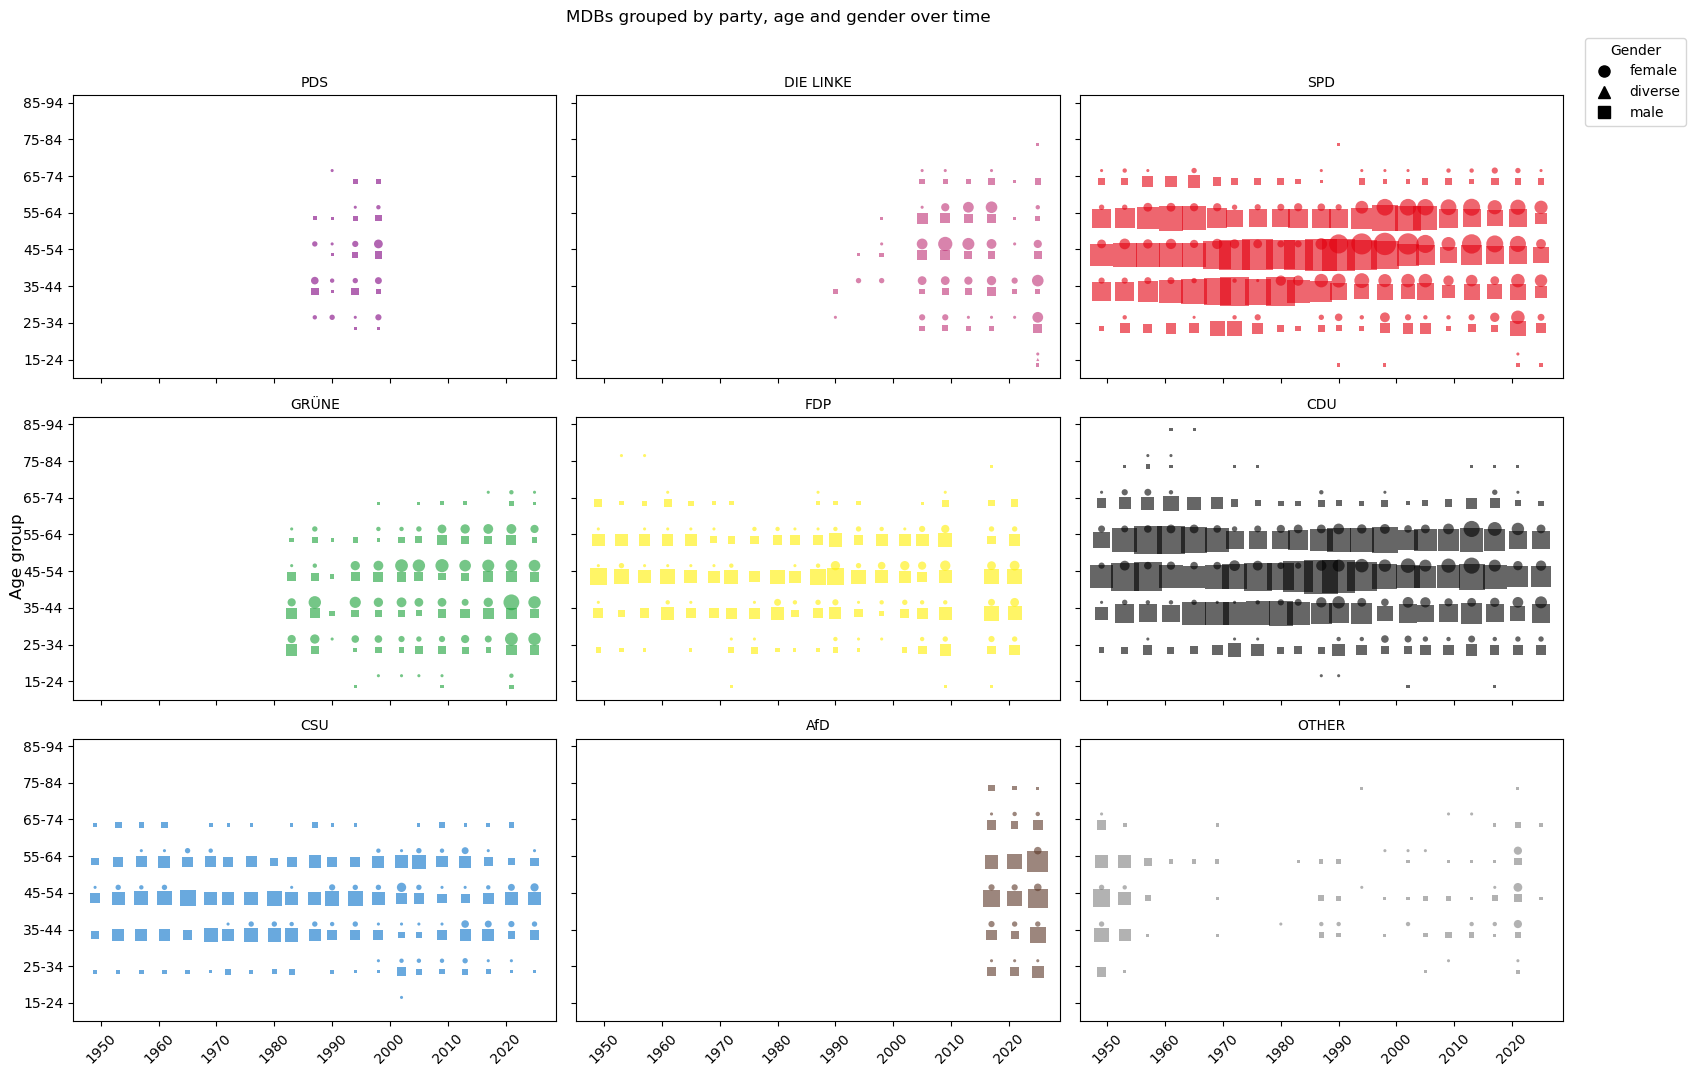

In [13]:
gender_markers = {
    'female': 'o',
    'diverse': '^',
    'male': 's'
}

gender_offsets_y = {
    'female': 0.15,
    'diverse': 0.0,
    'male': -0.15
}

parties = [p for p in party_colours if p in wp_df['Party'].unique()]
n_cols = 3
n_rows = -(-len(parties) // n_cols)

plot_df = wp_df.merge(terms_df[['WP', 'election_y_int']], on='WP')

age_group_to_y = {label: i for i, label in enumerate(age_labels)}
plot_df['y_pos'] = plot_df['Age_group'].map(age_group_to_y).astype(float)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5), sharex=True, sharey=True)
axes = axes.flatten()

for i, party in enumerate(parties):
    ax = axes[i]
    df_p = plot_df[plot_df['Party'] == party]
    color = party_colours[party]

    for gender, marker in gender_markers.items():
        df_g = df_p[df_p['Gender'] == gender]

        counts = (
            df_g
            .groupby(['election_y_int', 'y_pos'])
            .size()
            .reset_index(name='count')
        )
        #counts = counts[counts['count'] >= 4]

        ax.scatter(
            counts['election_y_int'],
            counts['y_pos'] + gender_offsets_y[gender],
            s=(counts['count']) * 5,
            color=color,
            marker=marker,
            alpha=0.6,
            edgecolors='none'
        )

    ax.set_title(party, fontsize=10)
    ax.tick_params(axis='x', rotation=45)

ax_ref = axes[0]
ax_ref.set_yticks(range(len(age_labels)))
ax_ref.set_yticklabels(age_labels)

# Hide unused subplots
for j in range(len(parties), len(axes)):
    axes[j].set_visible(False)

# Shared legend for gender (shape)
from matplotlib.lines import Line2D
gender_legend = [
    Line2D([0], [0], marker=marker, color='black', linestyle='', markersize=8, label=gender)
    for gender, marker in gender_markers.items()
]
fig.legend(handles=gender_legend, title='Gender', loc='upper left', bbox_to_anchor=(1.0, 1))

fig.suptitle('MDBs grouped by party, age and gender over time', y=1.02)
fig.supylabel('Age group')
plt.tight_layout()
plt.show()

## 5. Prevalence of academic titles

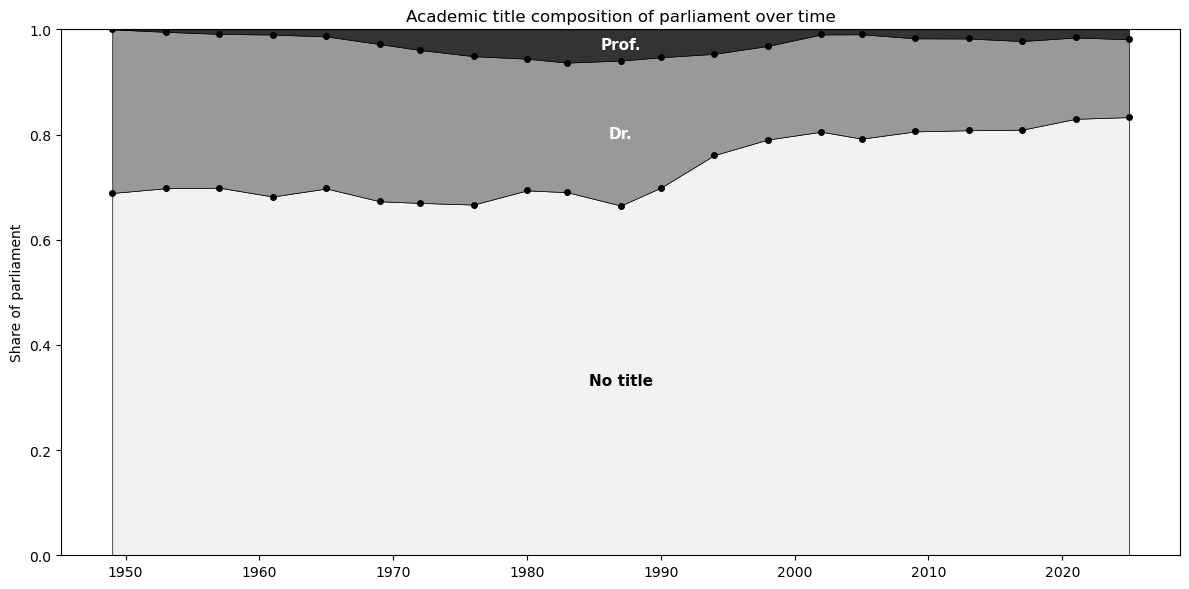

In [14]:
def categorize_acad_title(title):
    if pd.isna(title) or title is None:
        return 'No title'
    title = title.strip()
    if title.startswith('Prof'):
        return 'Prof.'
    elif title.startswith('Dr'):
        return 'Dr.'
    else:
        return 'No title'

wp_df['Acad_Title_cat'] = wp_df['Acad_Title'].apply(categorize_acad_title).astype('category')

title_shades = {
    'No title': '#f2f2f2',
    'Dr.': '#999999',
    'Prof.': '#333333'
}

# Weighted composition per WP (accounts for partial-term members via Frac_of_WP)
title_weight = (
    wp_df
    .groupby(['WP', 'Acad_Title_cat'], observed=True)['Frac_of_WP']
    .sum()
    .unstack(fill_value=0)
)

# Normalize to 100%
title_share = title_weight.div(title_weight.sum(axis=1), axis=0)

# Merge with election year for x-axis
title_share = title_share.merge(
    terms_df[['WP', 'election_y_int']], left_index=True, right_on='WP'
).sort_values('WP')

# Order: No title (bottom) -> Dr. -> Prof. (top)
categories = ['No title', 'Dr.', 'Prof.']

x = title_share['election_y_int'].values
ys = [title_share[cat].values for cat in categories]

fig, ax = plt.subplots(figsize=(12, 6))

ax.stackplot(
    x,
    ys,
    colors=[title_shades[cat] for cat in categories],
    edgecolor='black',
    linewidth=0.5
)

# Add points on each internal boundary line (skip the bottom y=0 and top y=1 lines)
cum = np.zeros(len(x))
boundaries = [cum.copy()]
for y in ys:
    cum = cum + y
    boundaries.append(cum.copy())

# boundaries[0] = y=0 (bottom), boundaries[-1] = y=1 (top) -> skip these two
for b in boundaries[1:-1]:
    ax.plot(x, b, color='black', linewidth=0.5, marker='o', markersize=4, linestyle='none')

# Text labels inside each band
mid_idx = len(x) // 2
mid_x = x[mid_idx]

cum_bottom = 0
for cat, y in zip(categories, ys):
    band_center = cum_bottom + y[mid_idx] / 2
    text_color = 'black' if cat == 'No title' else 'white'
    ax.text(
        mid_x, band_center, cat,
        ha='center', va='center',
        fontsize=11, color=text_color, fontweight='bold'
    )
    cum_bottom += y[mid_idx]

ax.set_ylabel('Share of parliament')
ax.set_xlabel('')
ax.set_title('Academic title composition of parliament over time')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 6.

In [15]:
# Total duration served as MDB, summed across all their terms (WP entries)
# Handle open-ended terms (MDBWP_UNTIL is NaT) by treating them as still ongoing until today

term_end = wp_df['MDBWP_UNTIL'].fillna(TODAY)
term_duration_days = (term_end - wp_df['MDBWP_FROM']).dt.days

total_duration = (
    wp_df
    .assign(term_duration_days=term_duration_days)
    .groupby('ID')['term_duration_days']
    .sum()
    .rename('Total_duration_days')
    .reset_index()
)
mdb_df = safe_merge(mdb_df, total_duration, ['ID'] )
mdb_df

,ID,First_name,Last_name,Acad_Title,Date_of_birth,Gender,Party,Marital_status,Children,Total_duration_days
0,11000001,Manfred,Abelein,Prof. Dr.,1930-10-20,male,CDU,no information / other,0,9109
1,11000002,Ernst,Achenbach,Dr.,1909-04-09,male,FDP,married,3,6912
2,11000003,Annemarie,Ackermann,None,1913-05-26,female,CDU,married,5,3196
3,11000004,Else,Ackermann,Dr.,1933-11-06,female,CDU,no information / other,0,1193
4,11000005,Ulrich,Adam,None,1950-06-09,male,CDU,married,2,6886
...,...,...,...,...,...,...,...,...,...,...
4609,11005623,Reza,Asghari,Prof. Dr.,1961-04-01,male,CDU,married,2,410
4610,11005624,Andrea,Lübcke,Dr.,1978-12-09,female,GRÜNE,no information / other,2,389
4611,11005625,Lisa,Schubert,None,2002-09-06,diverse,DIE LINKE,no information / other,0,358
4612,11005626,Mayra,Vriesema,None,1999-12-25,female,GRÜNE,no information / other,0,327


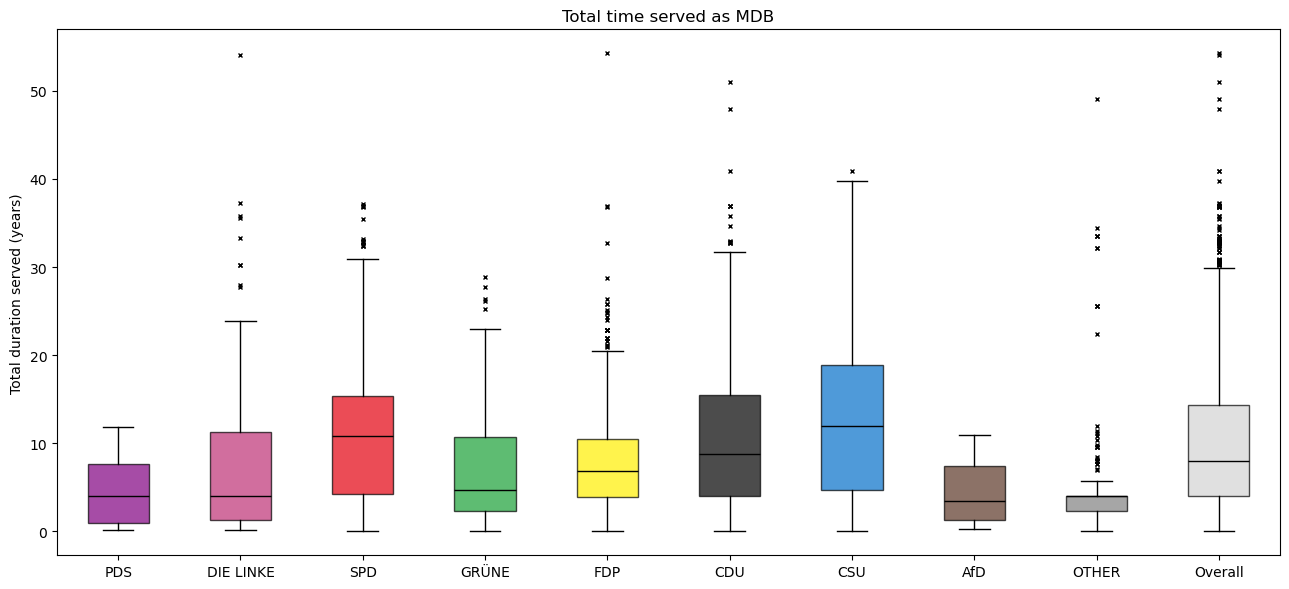

In [16]:


# --- 2) Total duration served by party boxplot (with "Overall" added) ---
duration_df = (
    mdb_df
    .dropna(subset=['Total_duration_days'])
    .assign(Total_duration_years=lambda d: d['Total_duration_days'] / 365.25)
)

party_order_dur = [p for p in party_colours if p in duration_df['Party'].unique()]
labels_dur = party_order_dur + ['Overall']

stats_dur = []
for party in party_order_dur:
    vals = duration_df.loc[duration_df['Party'] == party, 'Total_duration_years']
    s = compute_box_stats(vals)
    s['label'] = party
    stats_dur.append(s)

overall_dur_stats = compute_box_stats(duration_df['Total_duration_years'])
overall_dur_stats['label'] = 'Overall'
stats_dur.append(overall_dur_stats)

fig, ax = plt.subplots(figsize=(13, 6))
positions = range(1, len(stats_dur) + 1)

bxp_dict = ax.bxp(
    stats_dur,
    positions=positions,
    patch_artist=True,
    widths=0.5,
    showfliers=True,
    medianprops={'color': 'black'},
    flierprops={'marker': 'x', 'markersize': 3, 'alpha': 1}
)

for patch, label in zip(bxp_dict['boxes'], labels_dur):
    color = party_colours.get(label, 'lightgrey') if label != 'Overall' else 'lightgrey'
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(labels_dur)
ax.set_ylabel('Total duration served (years)')
ax.set_title('Total time served as MDB')
plt.tight_layout()
plt.show()

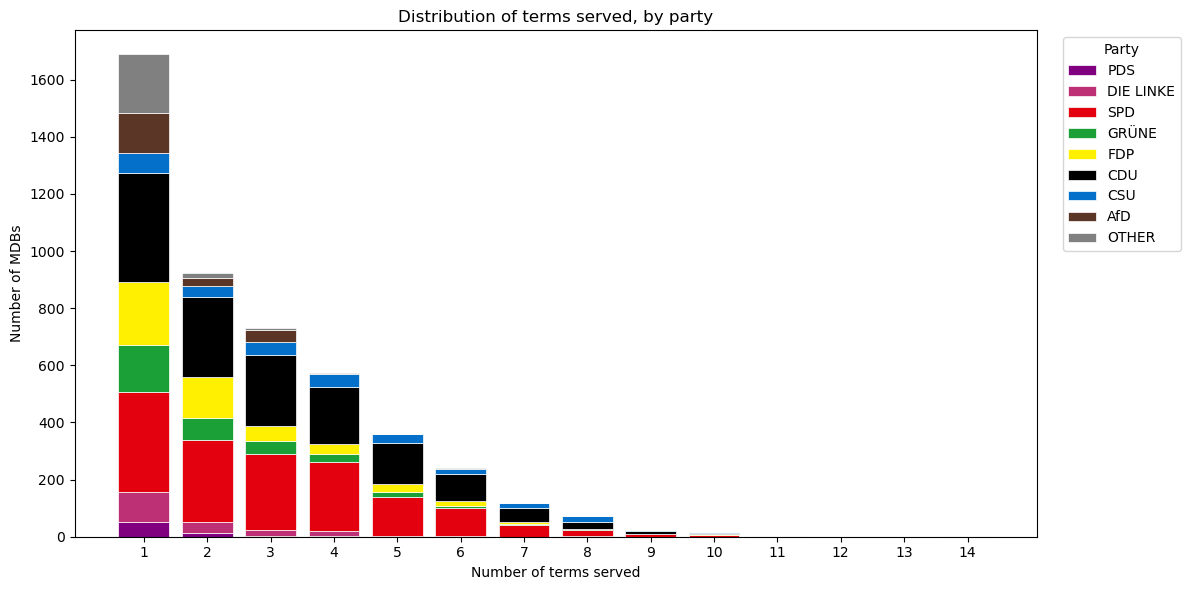

In [25]:
# Number of terms (WP entries) served per person, per party
terms_per_member_party = (
    wp_df
    .groupby(['ID', 'Party'])['WP']
    .nunique()
    .rename('n_terms')
    .reset_index()
)

party_order = [p for p in party_colours if p in terms_per_member_party['Party'].unique()]

max_terms = terms_per_member_party['n_terms'].max()
bins = range(1, max_terms + 2)  # integer bins: 1,2,3,...,max_terms

fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(max_terms)
for party in party_order:
    vals = terms_per_member_party.loc[terms_per_member_party['Party'] == party, 'n_terms']
    counts, _ = np.histogram(vals, bins=bins)
    ax.bar(
        range(1, max_terms + 1),
        counts,
        bottom=bottom,
        color=party_colours[party],
        label=party,
        width=0.8,
        edgecolor='white',
        linewidth=0.5
    )
    bottom += counts

ax.set_xlabel('Number of terms served')
ax.set_ylabel('Number of MDBs')
ax.set_title('Distribution of terms served, by party')
ax.set_xticks(range(1, max_terms + 1))
ax.legend(title='Party', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()